In [1]:
import numpy as np
import astropy.units as u
from astropy.constants import c
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from astropy.table import Table

import SED_Model
import lrt

import os
gd_folder = os.getcwd()+"/../../Calculations/SKIRTOR/"

import sys 
sys.path.append(gd_folder)
from loadSKIRTOR_MRN77_force_reg import LoadSKIRTOR_MRN77

sys.path.append("../utility_functions/")
from objectProperties import ObjectProperties

In [2]:
#Use the latex font when plotting. 
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [3]:
d20 = Table.read("../../SED_Modeling/double.20", format='ascii')
col_names = ['n_id', 'z', 'chi2', 'vec1', 'vec2', 'vec3', 'vec4', 'vec5']
for k, col_name in enumerate(col_names):
    d20.rename_column('col{}'.format(k+1),col_name)

In [4]:
d21 = Table.read("../../SED_Modeling/double.21", format='ascii')
col_names = ['n_id', 'jy', 'jymod', 'ejy', 'jyuse', 'lam_rest']
for k, col_name in enumerate(col_names):
    d21.rename_column('col{}'.format(k+1),col_name)

In [5]:
d22 = Table.read("../../SED_Modeling/double.22", format='ascii')
col_names = ['n_id', 'ebv1', 'ebv2', 'igm', 'wid']
for k, col_name in enumerate(col_names):
    d22.rename_column('col{}'.format(k+1),col_name)

In [6]:
p_data = Table.read("../../SED_Modeling/f_stat/comp.sort", format='ascii')
p_f = dict()
for i,wid in enumerate(p_data['col1']):
    p_f[wid] = p_data['col11'][i]

In [7]:
#We need to make a plot of the scattered light fraction as well. We can do this by dividing the best-fit secondary AGN SED and the data points by the best-fit primary model. 
def plot_scattered_sed(wid, ax, d20, d21, d22, pw=None, inclination=None, tang=None, cang=None):

    #Find position of the source
    ipos = np.where(d22['wid']==wid)[0][0]

    #Read the templates
    seds = np.loadtxt("../../SED_Modeling/agn_spec.dat", skiprows=1)
    lam_sed = seds[:,0]*u.micron
    s = np.zeros((5, len(lam_sed)))
    for i in range(4):
        s[i] = seds[:,i+2]
    s[-1] = seds[:,2] #Secondary AGN component.

    #Read the component amplitudes and scale the SED templates.
    vec = np.zeros(5)
    for i in range(5):
        vec[i] = d20['vec{}'.format(i+1)][ipos]
    for i in range(5):
        s[i] *= vec[i]   

    #Initiate the routines to load the reddening and IGM absorption. 
    lrt.kcinit("../../SED_Modeling/bandmag.dat",1,1,1,0)
    nw = lrt.wavegrid.nwave

    #The scattered light spectrum will correspond to the secondary AGN (with whatever obscuration is has) divided by the primary with no obscuration. 
    scattered_fnu = s[4]*10**(-0.4*lrt.dust.tau[:nw]*d22['ebv2'][ipos]) / s[0]

    #We also apply the IGM absorption for completeness. 
    tr_igm = np.array([lrt.transmit(lrt.wavegrid.bcen[k],d20['z'][ipos],d22['igm'][ipos]) for k in range(nw)])
    scattered_fnu *= tr_igm

    #Now we need to get the band fluxes of the unobscured primary AGN component. 
    z = d20['z'][ipos]
    agn1 = SED_Model.lrt_model()
    agn1.z = z
    agn1.zspec = z
    agn1.ebv = 0.
    agn1.igm = d22['igm'][ipos]
    agn1.comp = np.zeros(4)
    agn1.comp[0] = 1.0
    agn1.comp[0] *= d20['vec1'][ipos] / agn1.vec[0]
    agn1.get_model_fluxes()

    #Also, we need the host galaxy ones to substract them.
    gal = SED_Model.lrt_model()
    gal.z = z
    gal.zspec = z
    gal.ebv = 0.
    gal.igm = d22['igm'][ipos]
    gal.comp = np.ones(4)
    gal.comp[0] = 0.
    norm = np.array(list(d20['vec2','vec3','vec4'][ipos])) / gal.vec[1:]
    gal.comp[1:] *= norm
    gal.get_model_fluxes()

    #The scattered light fluxes will correspond to the observed fluxes divided by the expected fluxes from the primary AGN without absorption.
    k = np.argwhere(d21['n_id']==d20['n_id'][ipos])
    fnu_band_scatt  = (np.stack(d21['jy'][k],axis=1)[0] - gal.jymod) / agn1.jymod
    efnu_band_scatt = np.stack(d21['ejy'][k],axis=1)[0] / agn1.jymod
    lam_rest = np.stack(d21['lam_rest'][k],axis=1)[0] * u.micron

    #Plot the SED template fits.
    ax.plot(lam_sed, scattered_fnu*100., ls='dotted', c='gray', alpha=0.5, label='AGN SED Template')

    #Plot the observed scattered fluxes.
    cond = np.stack(d21['jyuse'][k],axis=1)[0]==1
    ax.plot(lam_rest.value[cond], fnu_band_scatt[cond]*100., marker='o', markersize=8, color='lime', linestyle='none')
    ax.errorbar(lam_rest.value[cond], fnu_band_scatt[cond]*100., yerr=efnu_band_scatt[cond]*100., fmt='o', markersize=8, color='black', fillstyle='none')

    #If plotting the model, let's first fit it to the data
    if pw is not None and inclination is not None:
        mod_scatt = pw.scatt_frac(([tang], [cang-10], [inclination], lam_rest.to(u.AA).value))

        cond = (lam_rest.to(u.AA).value>1216) & (lam_rest.to(u.AA).value<3500) & (np.stack(d21['jyuse'][k],axis=1)[0]==1)
        norm = np.sum(mod_scatt[cond]*fnu_band_scatt[cond]/efnu_band_scatt[cond]**2) / np.sum(mod_scatt[cond]**2/efnu_band_scatt[cond]**2)

        lam_grid = np.arange(1250., 3500., 20.)*u.AA
        ax.plot(lam_grid/1e4, 100*norm*pw.scatt_frac(([tang], [cang-10], [inclination], lam_grid)), label='SKIRT Model')

    ax.text(0.07, 0.80, wid, transform=ax.transAxes, fontsize=16, ha='left')
    ax.text(0.07, 0.68, r'$z = {0:.3f}$'.format(z), transform=ax.transAxes, fontsize=14, ha='left')
    ax.text(0.90, 0.80, r'$\eta = {:.0f}^{{\circ}}$'.format(inclination), transform=ax.transAxes, fontsize=14, ha='right')

    return


In [8]:
pw_l = LoadSKIRTOR_MRN77(cone_type='Full', interp_method='linear', get_scatt_frac=True)
#pw_p = LoadSKIRTOR_MRN77(cone_type='Full', interp_method='pchip', get_scatt_frac=True)

In [9]:
#Load the properties of the BHDs
op = ObjectProperties()

In [10]:
#Read the best-fit angles. 
x_best = np.loadtxt("../SKIRTOR_fit/combined_best_fit.txt", usecols=[0])
tang = x_best[0]
cang = x_best[1]
inclinations = dict()
for i, wid in enumerate(op.wids):
    inclinations[wid] = x_best[2+i]

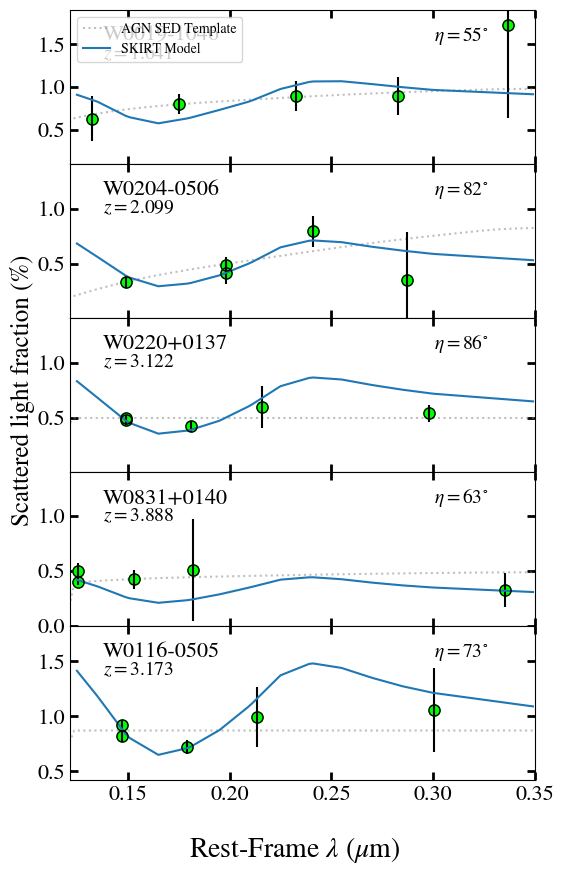

In [11]:
#Create the figure.
fig, axs = plt.subplots(5,1, figsize=(6, 10), sharex=True)#, sharey=True)

ylims = {
    'W0019-1046':[0.10, 1.9],
    'W0116-0505':[0.42, 1.82],
    'W0204-0506':[0.01, 1.41],
    'W0220+0137':[0.01, 1.41],
    'W0831+0140':[0.00, 1.40]
}

#Set the log scale.
for i, ax in enumerate(axs.ravel()):
    #ax.set_xscale('log')
    #ax.set_yscale('log')

    #Set the limits.
    ax.set_xlim([0.1216, 0.35])
    #ax.set_ylim([0.05, 1.9])
    ax.set_ylim(ylims[op.wids[i]])

    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='both', which='both', direction='in', labelsize=16, width=2, length=6, top=True, right=True)

for i, ax in enumerate(axs.ravel()):
    plot_scattered_sed(op.wids[i], ax, d20, d21, d22, pw=pw_l, inclination=inclinations[op.wids[i]], tang=tang, cang=cang)
    ax.set_ylim(ylims[op.wids[i]])
    if i==0:
        ax.legend()
        
    
#Set the axis labels
fig.supxlabel("Rest-Frame $\lambda$ ($\mu$m)", fontsize=20, y=0.025)
fig.supylabel("Scattered light fraction (%)", fontsize=18, x=0.025)

plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig("Scattered_light_fractions.png", dpi=200, bbox_inches='tight')